# Calogero-Sutherland model in a harmonic trap (1D)

`N` particles on a line, harmonically trapped, interacting through the inverse-square
Calogero-Sutherland potential. In the code convention $\hbar^2/m = 1$ (kinetic
$=-\sum_i\partial_i^2$, **not** $-\tfrac12\partial_i^2$):

$$ H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1)\sum_{i<j}\frac{1}{(x_i-x_j)^2} $$

**Exact ground state** (Calogero):

$$ \psi_0(x) = C \prod_{i<j}|x_i-x_j|^{L}\,\exp\!\Big(-\tfrac12\sum_i x_i^2\Big),\qquad \log|\psi_0| = L\sum_{i<j}\log|x_i-x_j| - \tfrac12\sum_i x_i^2 $$

**Exact energy** (in this $\omega=1$ convention):
$$ E_0 = N\big(1 + L(N-1)\big), \qquad E_0/N = 1 + L(N-1). $$

This is the CS analogue of the `soft_sphere_gas` notebook: a **parametrised setup** that
builds the `CalogeroSutherlandHamiltonian`, trains an ansatz, and wraps everything in
`run_cs(...)` so you can scan the coupling `L` (or `N`) and compare against the exact $E_0$.

All machinery lives in `qvarnet`:
`qvarnet.hamiltonian.continuous.CalogeroSutherlandHamiltonian`,
`qvarnet.models.analytic.CalogeroSutherlandAnalyticModel`, and `LogJastrow`.

## Imports

In [1]:
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import flax.linen as nn

# NOTE: import train from qvarnet.vmc.train, NOT `from qvarnet import train` —
# the legacy qvarnet/train.py shim shadows the function in mixed import orders.
from qvarnet.vmc.train import train
from qvarnet import evaluate_result
from qvarnet.config.training_setup import TrainingConfig, parse_sampler_params
from qvarnet.config.coord_mode import LabCoords
from qvarnet.boundaries import NoBoundary
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.models.jastrow import LogJastrow
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

## 0. Parameters

`L` is the CS coupling (the exact Jastrow exponent $\lambda = L$). `L>1` is repulsive,
`L<1` attractive (and harder). The interaction strength is $g = 2L(L-1)$.

In [3]:
N      = 5          # number of particles
N_DIM  = 1          # CS is a 1-D model
L      = 0.8        # CS coupling (THE scan knob); exact lambda = L
EPS    = 1e-12      # softens the 1/(x_i-x_j)^2 singularity (small but nonzero)

DoF = N * N_DIM
E_exact_total = N * (1 + L * (N - 1))          # code convention, omega=1
E_exact_per_n = E_exact_total / N
print(f'N={N}, L={L}  ->  g = 2L(L-1) = {2*L*(L-1):.3f}')
print(f'Exact E0 = {E_exact_total:.4f}   (E0/N = {E_exact_per_n:.4f})')

N=5, L=0.8  ->  g = 2L(L-1) = -0.320
Exact E0 = 21.0000   (E0/N = 4.2000)


## 1. Ansatz and Hamiltonian

Two ready options:

- **Analytic** (`CalogeroSutherlandAnalyticModel`): the exact log-$\psi$ with a single learnable
  $\lambda$. Converges to the exact energy — the validation baseline.
- **MLP + Gaussian envelope + Jastrow**: a flexible NN ansatz (`LogWavefunction`). The `LogJastrow`
  supplies the $\lambda\sum_{i<j}\log|x_i-x_j|$ cusp that the smooth MLP cannot represent.

`CalogeroSutherlandHamiltonian(L=L, epsilon=EPS)` supplies the kinetic + trap + inverse-square
interaction (the factor-of-2 conventions are handled inside).

In [4]:
LAMBDA_INIT = 1.2   # starting guess for the Jastrow exponent; should drift toward L



class NoNetwork(nn.Module):
    """Network that contributes nothing to log|ψ|: returns zeros of shape (..., 1).

    LogWavefunction sums network + envelope + jastrow, each expected as (..., 1).
    Returning x (shape (..., N)) would broadcast log|ψ| to a vector AND inject the
    raw coordinates into the wavefunction. A constant 0 leaves only envelope+jastrow.
    """
    @nn.compact
    def __call__(self, x):
        return jnp.zeros((*x.shape[:-1], 1))

def make_model(kind='mlp_jastrow', lambda_init=LAMBDA_INIT):
    if kind == 'analytic':
        return CalogeroSutherlandAnalyticModel(lambda_init=lambda_init)
    if kind == 'mlp_jastrow':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[128]),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
        )
    if kind == 'mlp':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[128]),
            envelope=GaussianEnvelope(),
        )
    if kind == 'jastrow':

        return LogWavefunction(
            transform=NoBoundary(),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
            network=NoNetwork(),
        )
    raise ValueError(kind)

def make_hamiltonian(L, eps=EPS, laplacian_method='forward_ad'):
    # laplacian_method: 'forward_ad' | 'folx' (forward-Laplacian, one fused pass)
    #                   | 'hutchinson' | 'central_difference'
    return CalogeroSutherlandHamiltonian(L=L, epsilon=eps, laplacian_method=laplacian_method)

## 2. Train

Open-boundary Metropolis sampler (the trap confines the walkers). `is_update_step_size` adapts the
step to the target acceptance. `run_cs(...)` is the unit of a parameter study; `train()` prints
`TrainResult.summary()` at the end (best/final epoch, acceptance, wall time, n_params).

**No mean over the training history** — those samples come from a moving distribution, so their
average is not a physical estimator. The physical measurement happens in the *Evaluate* cell below
(frozen params, block-averaged error bars).

`laplacian_method='folx'` switches the kinetic term to the forward-Laplacian (value + jacobian +
laplacian in one fused pass); default is `'forward_ad'`.

Running CS: N=5, L=0.8, model=jastrow, laplacian=forward_ad  (exact E0=21.0000)


100%|██████████| 4000/4000 [00:12<00:00, 321.70it/s, E=21.4723, sigma_E=4.5664]  


── training summary ────────────────────────────────────────
epochs ran       : 4000   (0m 11.4s wall, 2 parameters)
final epoch      : E = 21.281536 ± 5.60e-02   σ_E = 3.5862
best epoch ( 3981) : E = 21.209278 ± 4.93e-02   σ_E = 3.1545
acceptance (tail): 0.498
best snapshot    : epoch 3981 (select metric = 3.15446; 3 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


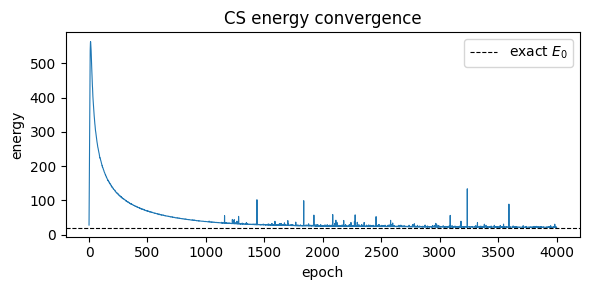

In [5]:
def run_cs(L, N=N, kind='mlp_jastrow', n_epochs=4000, n_chains=4096,
           lr=1e-3, lambda_init=LAMBDA_INIT, seed=0,
           laplacian_method='forward_ad'):   # 'forward_ad' | 'folx'
    '''Train the CS model at coupling L. Returns (result, ctx).

    ctx carries model/hamiltonian/shape/sampling_config so the evaluate cell can do
    `evaluate_result(result, **ctx)`. train() auto-prints TrainResult.summary().
    '''
    E0 = N * (1 + L * (N - 1))
    print(f'Running CS: N={N}, L={L}, model={kind}, laplacian={laplacian_method}  '
          f'(exact E0={E0:.4f})')
    model = make_model(kind, lambda_init)
    hamiltonian = make_hamiltonian(L, laplacian_method=laplacian_method)
    shape = (n_chains, N * N_DIM)
    sampler_params = {
        'step_size':            0.5,
        'chain_length':         21,
        'thermalization_steps': 20,
        'thinning_factor':      1,
        # open boundary (no box_L): the harmonic trap confines the walkers
    }
    cfg = TrainingConfig(
        n_epochs=n_epochs, rng_seed=seed,
        warm_walkers=True, is_update_step_size=True,
        min_step=1e-5, max_step=5.0,
        checkpoint_path='./checkpoints/cs',
    )
    result = train(
        shape=shape, model=model, optimizer=optax.adam(lr),
        hamiltonian=hamiltonian,
        training_config=cfg, sampler_params=sampler_params, coord_mode=LabCoords(),
    )
    ctx = dict(model=model, hamiltonian=hamiltonian, shape=shape,
               sampling_config=parse_sampler_params(sampler_params))
    return result, ctx

result, ctx = run_cs(L, kind="jastrow")
energies = np.array([float(s.energy) for s in result.history])
plt.figure(figsize=(6, 3))
plt.plot(energies, lw=0.8)
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

## 4. Scan the number of particles `N`

`run_cs(N=...)` + `evaluate_result` is the unit of a parameter study: train, then measure
the best snapshot with frozen params. The exact line $E_0/N = 1 + L(N-1)$ is the
validation target.

Running CS: N=5, L=0.8, model=mlp_jastrow, laplacian=forward_ad  (exact E0=21.0000)


100%|██████████| 5000/5000 [00:22<00:00, 220.53it/s, E=21.2274, sigma_E=2.6241] 


── training summary ────────────────────────────────────────
epochs ran       : 5000   (0m 21.4s wall, 899 parameters)
final epoch      : E = 21.246262 ± 5.41e-02   σ_E = 2.4502
best epoch ( 1177) : E = 18.853901 ± 3.56e+00   σ_E = 161.1334
acceptance (tail): 0.500
best snapshot    : epoch 4786 (select metric = 2.25277; 3 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
N=5: E/N = 4.2608 +/- 0.0005   (exact 4.2000)


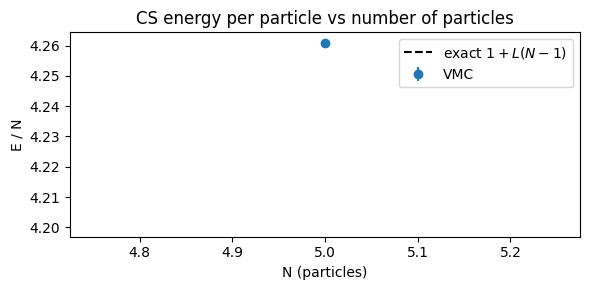

In [ ]:
N_scan = [5]
rows = []
for N in N_scan:
    res_i, ctx_i = run_cs(L=L, N=N, n_epochs=15_000, n_chains=4096)
    ev_i = evaluate_result(res_i, **ctx_i, sample_factor=0.2)
    print(f'N={N}: E/N = {ev_i.energy / N:.4f} +/- {ev_i.error / N:.4f}   '
          f'(exact {1 + L * (N - 1):.4f})')
    rows.append((N, ev_i.energy / N, ev_i.error / N, 1 + L * (N - 1)))

Ns   = [r[0] for r in rows]
plt.figure(figsize=(6, 3))
plt.errorbar(Ns, [r[1] for r in rows], yerr=[r[2] for r in rows], fmt='o', label='VMC')
plt.plot(Ns, [r[3] for r in rows], 'k--', label='exact $1+L(N-1)$')
plt.xlabel('N (particles)'); plt.ylabel('E / N'); plt.legend()
plt.title('CS energy per particle vs number of particles'); plt.tight_layout(); plt.show()